In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [21]:
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_colour = "#00bfbf"

In [22]:
data = pd.read_csv('fake_news_data.csv')

In [23]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            198 non-null    str  
 1   text             198 non-null    str  
 2   date             198 non-null    str  
 3   fake_or_factual  198 non-null    str  
dtypes: str(4)
memory usage: 6.3 KB


Text(0.5, 1.0, 'Count of Article Classification')

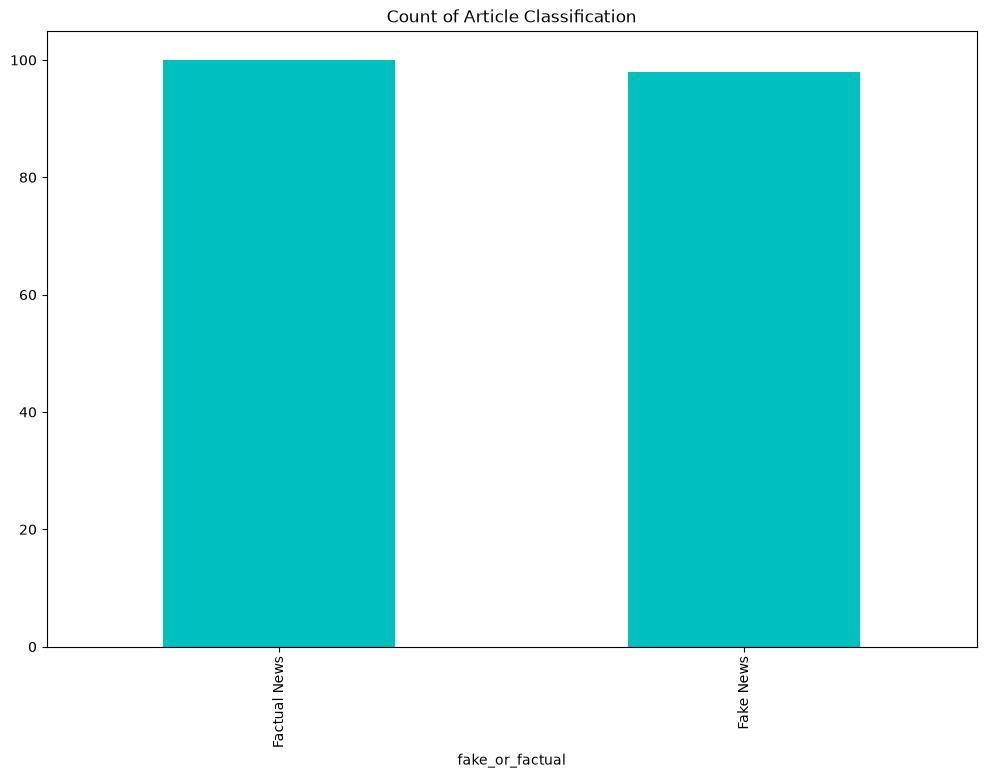

In [29]:
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title("Count of Article Classification")

In [95]:
nlp = spacy.load("en_core_web_sm")

In [96]:
fake_news = data[data["fake_or_factual"] == "Fake News"]
fact_news = data[data["fake_or_factual"] == "Factual News"]

In [97]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [98]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [99]:
fake_tagsdf = []
columns = ["token", "ner_tag", "pos_tag"]

In [100]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

In [101]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [102]:
fact_tagsdf = []

for ix, doc in enumerate (fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)

In [103]:
fact_tagsdf = pd.concat(fact_tagsdf)

In [104]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


### **Named Entities**

In [105]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [106]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != ""].groupby(["token", "ner_tag"]).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [107]:
ner_palette = {
     "ORG": sns.color_palette("Set2").as_hex()[0],
     "GPE": sns.color_palette("Set2").as_hex()[1],
     "NORP": sns.color_palette("Set2").as_hex()[2],
     "PERSON": sns.color_palette("Set2").as_hex()[3],
     "DATE": sns.color_palette("Set2").as_hex()[4],
     "CARDINAL": sns.color_palette("Set2").as_hex()[5],
     "PERCENT": sns.color_palette("Set2").as_hex()[6],
}

[Text(0.5, 1.0, 'Most Common Named Entities in Fake News')]

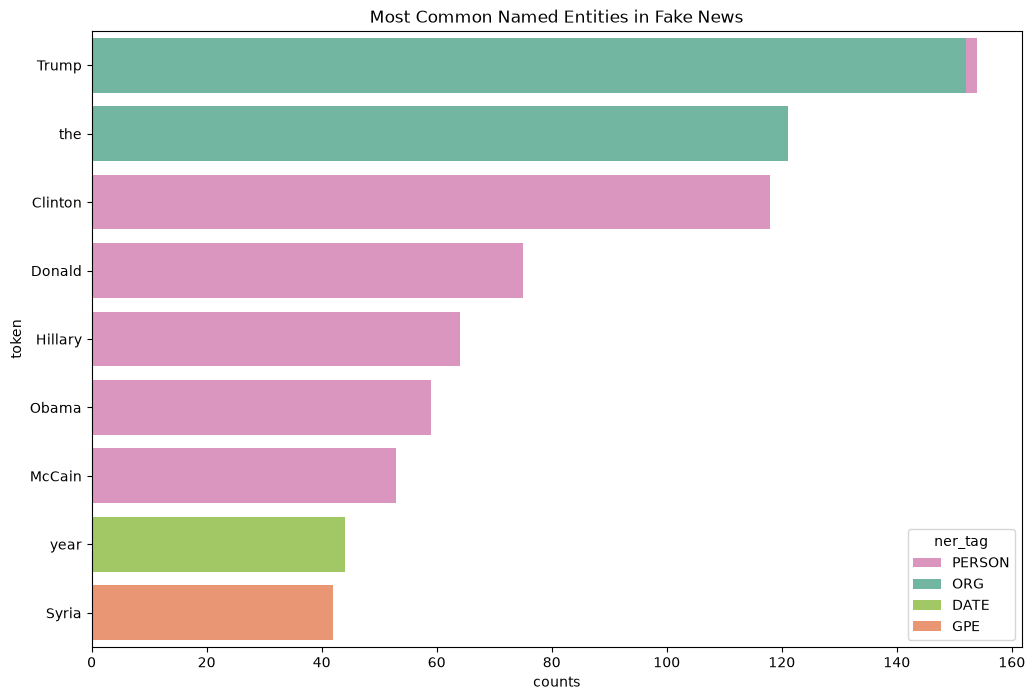

In [108]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False
).set(title="Most Common Named Entities in Fake News")

In [109]:
top_entities_fake[:10]

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


[Text(0.5, 1.0, 'Most Common Named Entities in Factula News')]

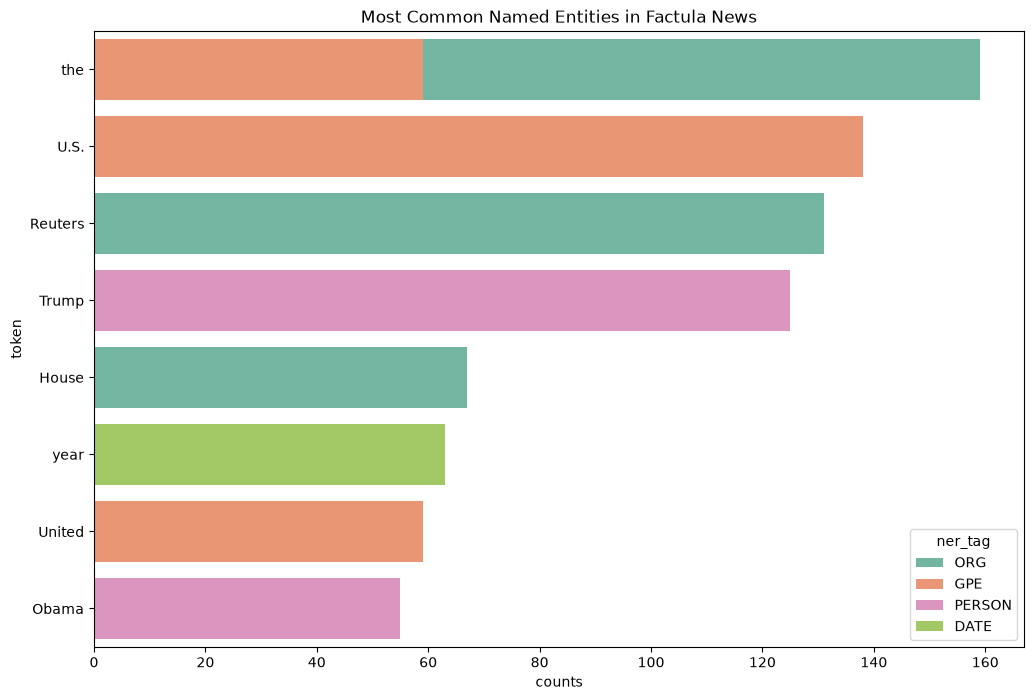

In [110]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[:10],
    orient = 'h',
    dodge = False
).set(title="Most Common Named Entities in Factula News")

### **Text Pre-Processing**

In [119]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,two small problems analogy susan jesus muslim ...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried trump bonkers interview new york times ...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make 50 percent country grossly underrep...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said monday ru...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland political parties rapidly run...


In [112]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s", "", x['text']), axis=1)

In [113]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,There are two small problems with your analogy...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,Buried in Trump s bonkers interview with New Y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"Women make up over 50 percent of this country,..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,U.S. Defense Secretary Jim Mattis said on Mond...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,Northern Ireland s political parties are rapid...


In [114]:
data['text_clean'] = data['text_clean'].str.lower()

In [115]:
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub(r'[^\s\w]', '', x))

In [116]:
en_stopwords = stopwords.words("english")

In [117]:
data['text_clean'] = data['text_clean'].apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))

In [120]:
data['text_clean'] = data['text_clean'].apply(lambda x: word_tokenize(x))

In [123]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [124]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [158]:
tokens_clean = sum(data['text_clean'], [])

In [159]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0       (trump,)    580
1        (said,)    580
2           (u,)    277
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    160
7     (clinton,)    141
8        (year,)    139
9  (republican,)    137


/var/folders/gh/1tv137sn70gcp9q2rxfz772w0000gn/T/ipykernel_11772/2436745763.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

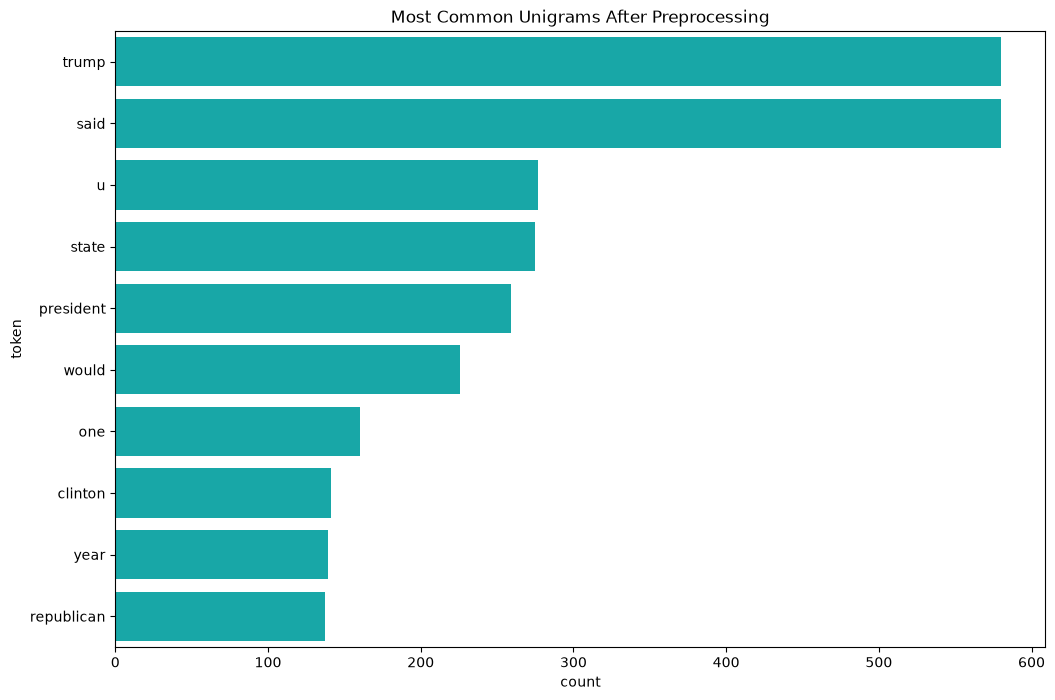

In [160]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(x="count", 
            y="token",
            data=unigrams,
            orient='h',
            palette=[default_plot_colour],
            hue="token", legend=False
           ).set(title="Most Common Unigrams After Preprocessing")

In [161]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()).reset_index()[:10]
print(bigrams)

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     33
6         (supreme, court)     30
7             (image, via)     29
8  (trump, administration)     26
9         (official, said)     26


In [183]:
data_fact = data[data["fake_or_factual"] == "Factual News"]

In [184]:
tokens_clean_fact = sum(data_fact["text_clean"], [])

In [185]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean_fact, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0        (said,)    452
1       (trump,)    267
2           (u,)    181
3       (state,)    165
4   (president,)    137
5       (would,)    129
6       (house,)     81
7  (government,)     77
8       (court,)     77
9        (year,)     70


/var/folders/gh/1tv137sn70gcp9q2rxfz772w0000gn/T/ipykernel_11772/2436745763.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

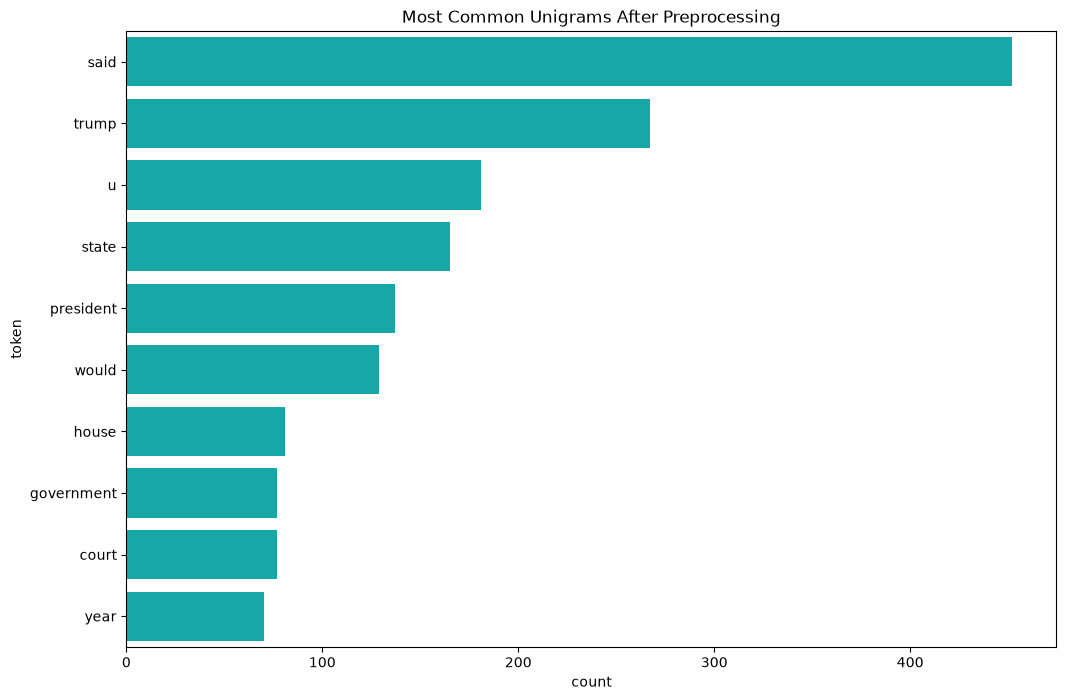

In [186]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(x="count", 
            y="token",
            data=unigrams,
            orient='h',
            palette=[default_plot_colour],
            hue="token", legend=False
           ).set(title="Most Common Unigrams After Preprocessing")

In [179]:
data_fake = data[data["fake_or_factual"] == "Fake News"]

In [180]:
tokens_clean_fake = sum(data_fake["text_clean"], [])

In [181]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean_fake, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0       (trump,)    313
1        (said,)    128
2   (president,)    122
3     (clinton,)    111
4       (state,)    110
5       (would,)     97
6           (u,)     96
7         (one,)     93
8        (time,)     85
9  (republican,)     79


/var/folders/gh/1tv137sn70gcp9q2rxfz772w0000gn/T/ipykernel_11772/2436745763.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

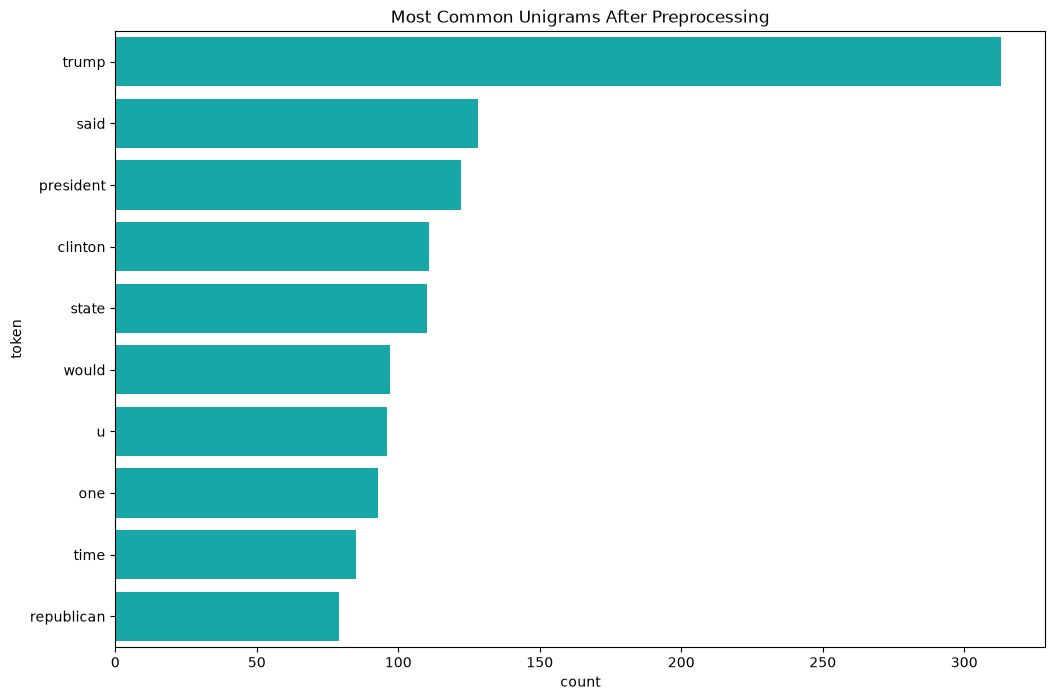

In [182]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(x="count", 
            y="token",
            data=unigrams,
            orient='h',
            palette=[default_plot_colour],
            hue="token", legend=False
           ).set(title="Most Common Unigrams After Preprocessing")

### **Sentiment Analysis**

In [187]:
vader_sentiment = SentimentIntensityAnalyzer()

In [189]:
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [191]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [193]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

In [194]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

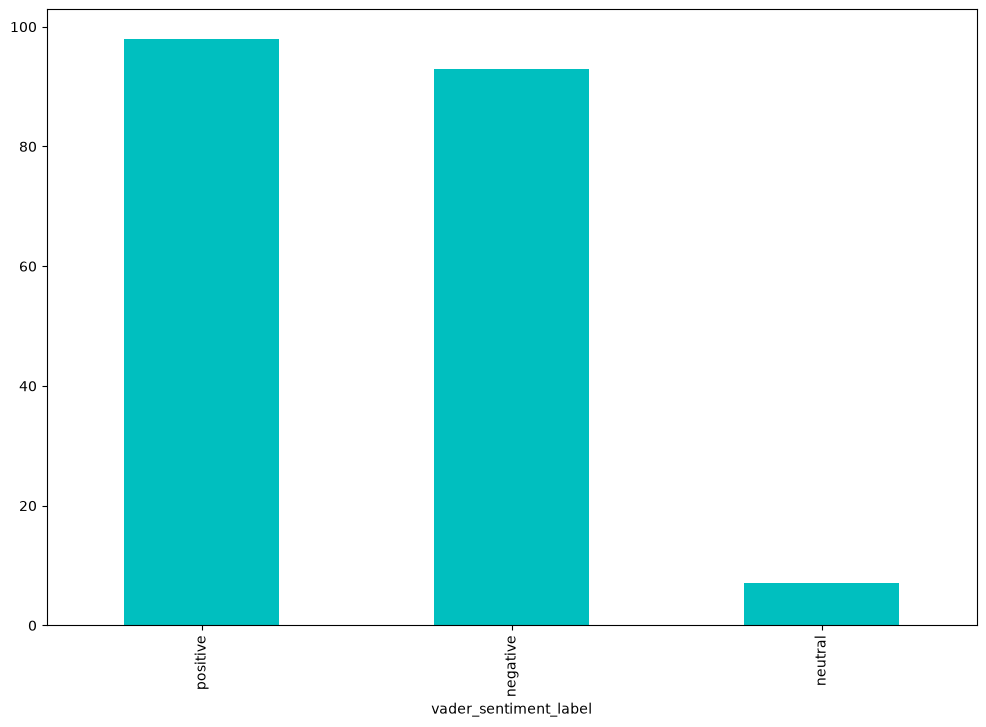

In [197]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/var/folders/gh/1tv137sn70gcp9q2rxfz772w0000gn/T/ipykernel_11772/4271844426.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

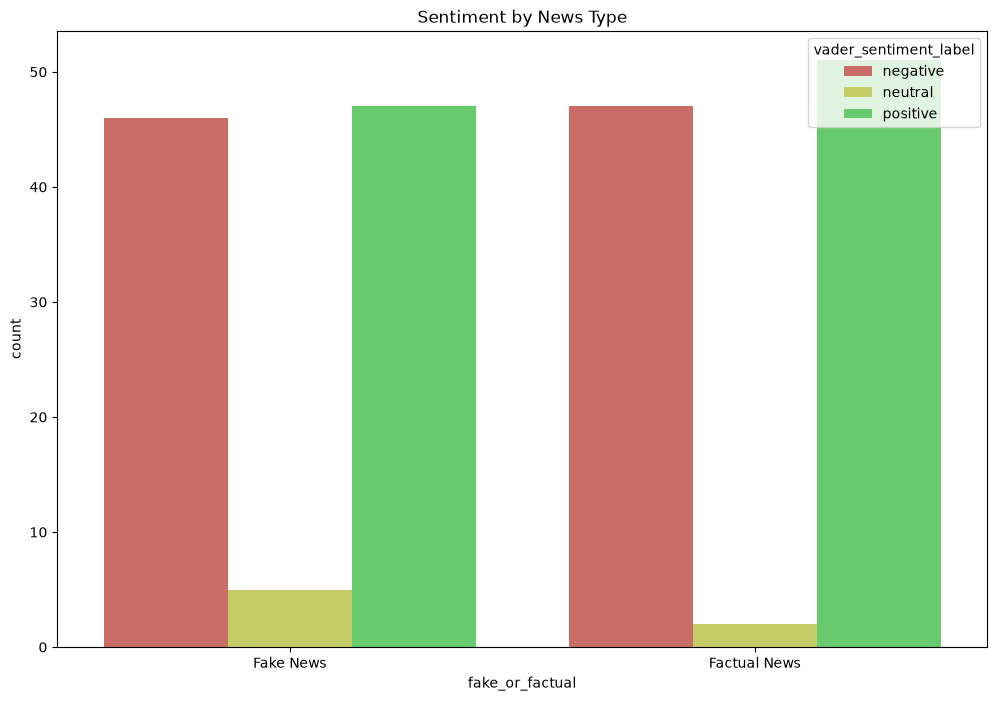

In [199]:
sns.countplot(
    x = "fake_or_factual",
    hue="vader_sentiment_label",
    palette = sns.color_palette('hls'),
    data = data
).set(title="Sentiment by News Type")

In [202]:
fake_news_text = data[data['fake_or_factual']  == "Fake News"]["text_clean"].reset_index(drop=True)

In [203]:
dictionary_fake = corpora.Dictionary(fake_news_text)

In [204]:
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]